# TakaPay Social Listening — Exploratory Analysis

Exploratory analysis of 660 social media posts mentioning TakaPay (fictional
mobile wallet brand), across Facebook, Reddit, Instagram, YouTube, TikTok,
Twitter, and News/Media, in Bangla/English/mixed text.

**No LLM calls in this notebook** — pure pandas/matplotlib analysis on the
labeled fields already present in the data (`sentiment`, `sentiment_score`,
`topic`, `platform`, `language`, `reactions`, `comments`).

### How to use in Colab
1. Upload `takapay_sample_data.json` when prompted by the cell below (or place it in
   the same Colab working directory beforehand).
2. Run all cells top to bottom.


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110


## 1. Load the data

In [2]:
# In Colab: this will prompt a file upload dialog if takapay_sample_data.json isn't
# already present in the working directory. Locally / non-Colab, it just
# reads the file directly.
import os

if not os.path.exists("takapay_sample_data.json"):
    try:
        from google.colab import files
        print("Please upload takapay_sample_data.json")
        uploaded = files.upload()
    except ImportError:
        raise FileNotFoundError(
            "takapay_sample_data.json not found. Place it in the working directory."
        )

with open("takapay_sample_data.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Loaded {len(df)} records, columns: {list(df.columns)}")
df.head()

Loaded 660 records, columns: ['id', 'platform', 'timestamp', 'author', 'text', 'language', 'brand_mention', 'sentiment', 'sentiment_score', 'topic', 'reactions', 'comments']


,id,platform,timestamp,author,text,language,brand_mention,sentiment,sentiment_score,topic,reactions,comments
0,1017,TikTok,2026-06-21 01:16:00,Farhana15,"TakaPay helpline e 30 min wait korlam, keu dhorlo na.",bn-en,True,negative,8,customer_care,174,76
1,1173,TikTok,2026-06-08 23:49:00,Sabbir77,Paid my gas bill on TakaPay in under a minute. Genuinely smooth experience.,en,True,positive,88,bill_payment,40,106
2,1043,YouTube,2026-06-25 04:05:00,Tuhin27,Paid my internet bill on TakaPay in under a minute. Genuinely smooth experience.,en,True,positive,92,bill_payment,148,57
3,1506,YouTube,2026-06-21 09:11:00,Priya7,আমার একাউন্ট থেকে 5000 টাকা কেটে নিয়েছে কিন্তু Grameenphone রিচার্জ হয়নি। TakaPay এর কোনো হেল্প নেই।,bn,True,negative,27,failed_transaction,278,85
4,1325,Facebook,2026-06-14 23:05:00,Arif65,TakaPay agent kothay pabo Farmgate te? Cash out korte hobe.,bn-en,True,neutral,50,agent_network,335,41


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               660 non-null    int64         
 1   platform         660 non-null    object        
 2   timestamp        660 non-null    datetime64[ns]
 3   author           660 non-null    object        
 4   text             660 non-null    object        
 5   language         660 non-null    object        
 6   brand_mention    660 non-null    bool          
 7   sentiment        660 non-null    object        
 8   sentiment_score  660 non-null    int64         
 9   topic            660 non-null    object        
 10  reactions        660 non-null    int64         
 11  comments         660 non-null    int64         
dtypes: bool(1), datetime64[ns](1), int64(4), object(6)
memory usage: 57.5+ KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,660.0,NaN,NaN,NaN,1330.5,1001.0,1165.75,1330.5,1495.25,1660.0,190.669872
platform,660,7,Facebook,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,660,NaN,NaN,NaN,2026-06-16 02:42:44.727272960,2026-06-01 01:26:00,2026-06-09 00:01:30,2026-06-16 08:00:00,2026-06-23 11:05:30,2026-06-30 23:50:00,NaN
author,660,583,Rifat65,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,660,650,"Instant Airtel recharge on TakaPay, 2500 taka, done before I finished my tea.",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,660,3,bn-en,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand_mention,660,1,True,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment,660,3,negative,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_score,660.0,NaN,NaN,NaN,44.584848,6.0,17.0,30.0,76.0,94.0,29.958956
topic,660,15,failed_transaction,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data quality checks

Before drawing any conclusions, it's worth checking whether the labels in
the data can actually be trusted at face value.


### 2.1 `brand_mention` is `True` for every single row — including posts that clearly aren't about TakaPay

The `topic` field has an `off_topic` category (traffic complaints, food
recommendations, exam stress, etc.) that has nothing to do with the brand.
These should be excluded from brand-sentiment metrics, even though they're
flagged `brand_mention=True` in the raw data.


In [5]:
print("brand_mention value counts:")
print(df["brand_mention"].value_counts())
print()

off_topic = df[df["topic"] == "off_topic"]
print(f"off_topic rows: {len(off_topic)} ({len(off_topic)/len(df):.1%} of all data)")
off_topic[["platform", "text", "sentiment"]].head(8)


brand_mention value counts:
brand_mention
True    660
Name: count, dtype: int64

off_topic rows: 61 (9.2% of all data)


,platform,text,sentiment
23,Reddit,"Traffic ajke Farmgate e insane, 2 ghonta laglo pouchte.",positive
61,YouTube,"Kal semester final, ekhono porini kichui 😭",neutral
63,Twitter,"Ei Farmgate er biryani ta must try, khub valo.",neutral
65,Twitter,"Ei Mohakhali er biryani ta must try, khub valo.",neutral
67,Facebook,"Traffic ajke Chittagong e insane, 2 ghonta laglo pouchte.",neutral
69,TikTok,"Ajke Dhanmondi 27 te prochur bristi, office jete 1 ghonta deri hoye gelo.",positive
80,Facebook,"Ei Bashundhara er biryani ta must try, khub valo.",neutral
84,TikTok,"Ajke Gulshan 1 te prochur bristi, office jete 1 ghonta deri hoye gelo.",positive


In [6]:
# Build the "brand-relevant" dataframe used for all sentiment analysis below
df_brand = df[df["topic"] != "off_topic"].copy()
print(f"Brand-relevant records: {len(df_brand)} (excluded {len(df) - len(df_brand)} off-topic)")

Brand-relevant records: 599 (excluded 61 off-topic)


### 2.2 Sentiment label vs. sentiment_score disagreements

A handful of rows have a `sentiment` label that disagrees with the numeric
`sentiment_score` (e.g. labeled `negative` but score > 50). These are flagged
rather than silently corrected — we can't verify which field is the error.


In [7]:
def is_mismatch(row):
    s, sc = row["sentiment"], row["sentiment_score"]
    if s == "positive" and sc < 50:
        return True
    if s == "negative" and sc > 50:
        return True
    if s == "neutral" and (sc > 70 or sc < 30):
        return True
    return False

mismatches = df[df.apply(is_mismatch, axis=1)]
print(f"{len(mismatches)} rows with sentiment/score disagreement")
mismatches[["platform", "text", "sentiment", "sentiment_score"]]

6 rows with sentiment/score disagreement


,platform,text,sentiment,sentiment_score
23,Reddit,"Traffic ajke Farmgate e insane, 2 ghonta laglo pouchte.",positive,46
137,News/Media,"Ajke Mirpur 10 te prochur bristi, office jete 1 ghonta deri hoye gelo.",positive,48
211,Facebook,"Notun phone kinbo vabtesi, keu Airtel er offer jano?",positive,49
220,Facebook,"Ajke Mohakhali te prochur bristi, office jete 30 min deri hoye gelo.",positive,47
483,Facebook,"Ajke Gulshan 1 te prochur bristi, office jete 2 ghonta deri hoye gelo.",positive,48
591,Facebook,"Ei Uttara er biryani ta must try, khub valo.",positive,48


### 2.3 Duplicate / templated posts

Some posts are near-identical templates with a swapped noun (a telecom
operator name, an area name). Consistent with synthetically generated
sample data — kept in the analysis since they still carry real topic/
sentiment signal, but worth knowing about.


In [8]:
dupe_counts = df["text"].value_counts()
dupes = dupe_counts[dupe_counts > 1]
print(f"{len(dupes)} distinct texts appear more than once, {dupes.sum()} records total")
dupes.head(10)

10 distinct texts appear more than once, 20 records total


,count
text,
"Instant Airtel recharge on TakaPay, 2500 taka, done before I finished my tea.",2
5000 taka TakaPay theke katlo but receiver pay nai. 2 din dhore atke ache.,2
"Instant Robi recharge on TakaPay, 2500 taka, done before I finished my tea.",2
"Transaction fail holo tao 2000 taka kete nilo, TakaPay er kono response nai.",2
TakaPay দিয়ে tuition fee দেওয়া যায় কিনা কেউ বলতে পারবেন?,2
"TakaPay OTP ashteci na, 2 ghonta dhore login e atke achi. Fix koro please.",2
"Transaction fail holo tao 5000 taka kete nilo, TakaPay er kono response nai.",2
"TakaPay diye baba ke 5000 taka pathalam, 3 din hoye gelo ekhono pending!",2
আমার একাউন্ট থেকে 5000 টাকা কেটে নিয়েছে কিন্তু Grameenphone রিচার্জ হয়নি। TakaPay এর কোনো হেল্প নেই।,2


## 3. Overall sentiment picture

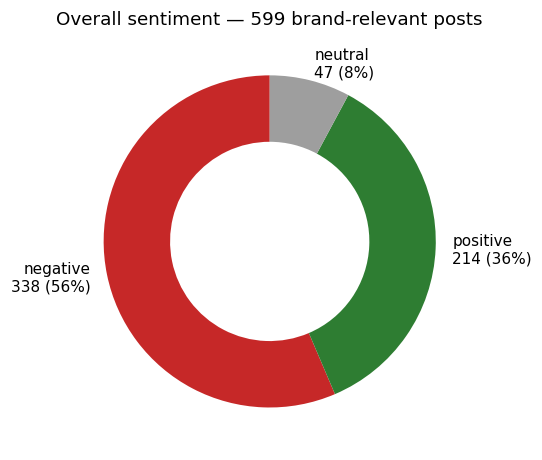

sentiment
negative    338
positive    214
neutral      47
Name: count, dtype: int64
Average sentiment_score: 43.7 / 100


In [9]:
sentiment_counts = df_brand["sentiment"].value_counts()
colors = {"positive": "#2e7d32", "negative": "#c62828", "neutral": "#9e9e9e"}

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    sentiment_counts.values,
    labels=[f"{i}\n{v} ({v/len(df_brand):.0%})" for i, v in sentiment_counts.items()],
    colors=[colors[i] for i in sentiment_counts.index],
    startangle=90,
    wedgeprops={"width": 0.4},
)
ax.set_title(f"Overall sentiment — {len(df_brand)} brand-relevant posts")
plt.tight_layout()
plt.show()

print(sentiment_counts)
print(f"Average sentiment_score: {df_brand['sentiment_score'].mean():.1f} / 100")


## 4. Sentiment by platform

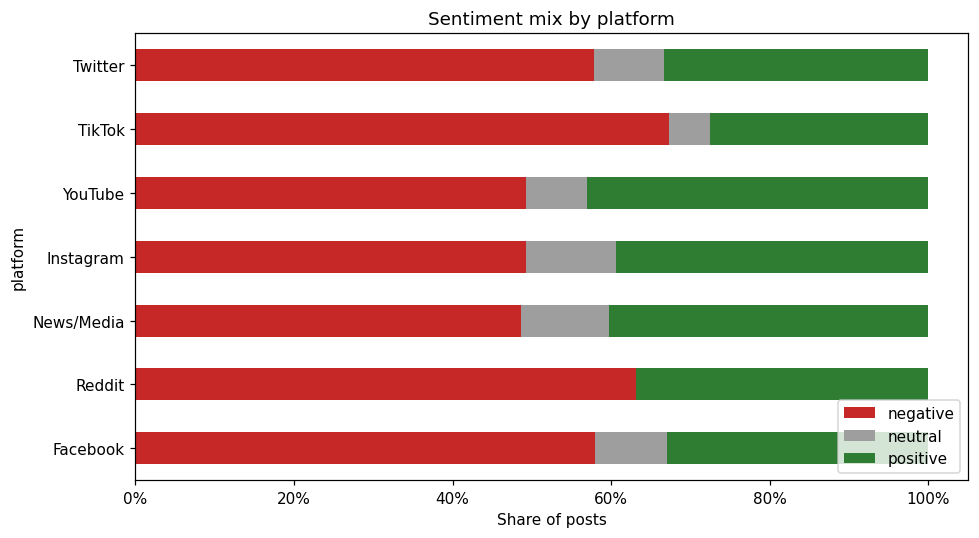

sentiment,negative,neutral,positive
platform,,,
Facebook,116,18,66
Reddit,48,0,28
News/Media,35,8,29
Instagram,35,8,28
YouTube,32,5,28
TikTok,39,3,16
Twitter,33,5,19


In [10]:
platform_sentiment = pd.crosstab(df_brand["platform"], df_brand["sentiment"])
platform_sentiment = platform_sentiment.loc[platform_sentiment.sum(axis=1).sort_values(ascending=False).index]
platform_sentiment_pct = platform_sentiment.div(platform_sentiment.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
platform_sentiment_pct[["negative", "neutral", "positive"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=[colors["negative"], colors["neutral"], colors["positive"]],
)
ax.set_xlabel("Share of posts")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Sentiment mix by platform")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

platform_sentiment


## 5. What are people actually talking about? (topic frequency)

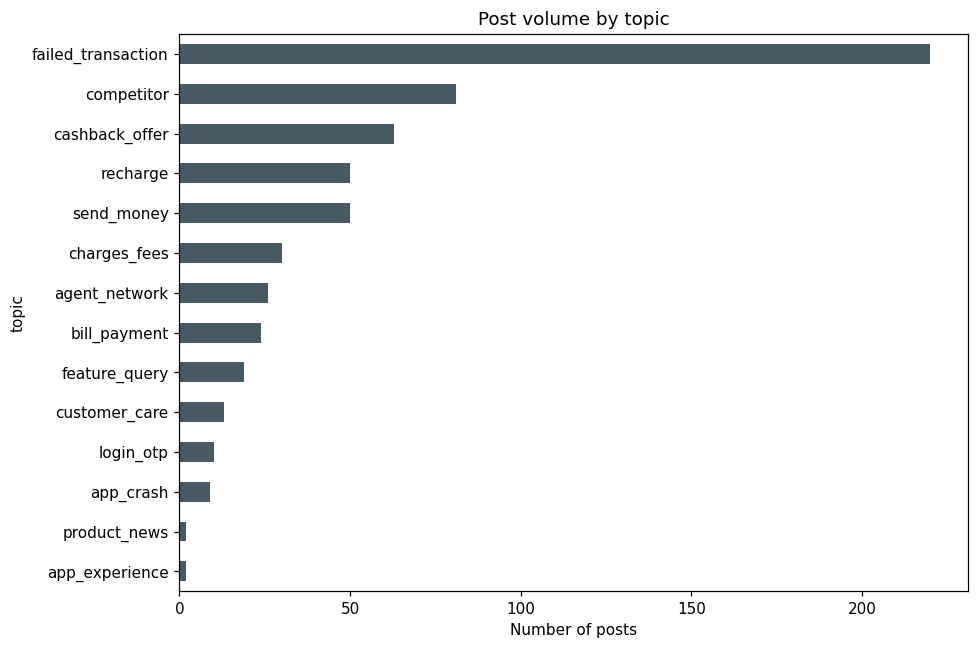

,count
topic,
failed_transaction,220
competitor,81
cashback_offer,63
send_money,50
recharge,50
charges_fees,30
agent_network,26
bill_payment,24
feature_query,19


In [11]:
topic_counts = df_brand["topic"].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
topic_counts.sort_values().plot(kind="barh", ax=ax, color="#455a64")
ax.set_xlabel("Number of posts")
ax.set_title("Post volume by topic")
plt.tight_layout()
plt.show()

topic_counts


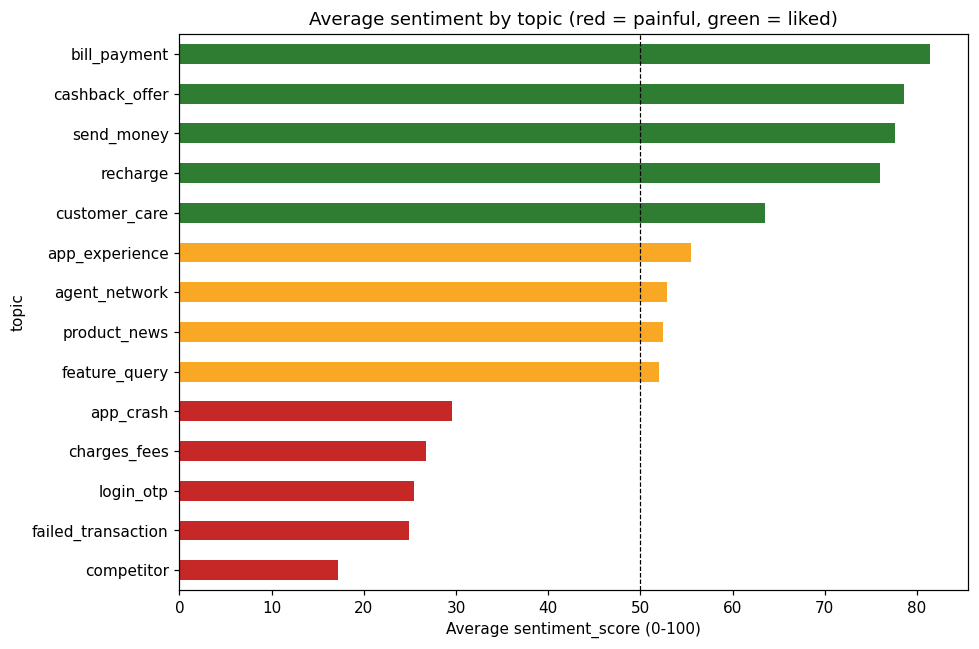

In [12]:
# Average sentiment score per topic — which topics are the most painful,
# not just the most frequent
topic_score = df_brand.groupby("topic")["sentiment_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ["#c62828" if v < 40 else "#f9a825" if v < 60 else "#2e7d32" for v in topic_score.values]
topic_score.plot(kind="barh", ax=ax, color=bar_colors)
ax.set_xlabel("Average sentiment_score (0-100)")
ax.set_title("Average sentiment by topic (red = painful, green = liked)")
ax.axvline(50, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

## 6. Sentiment trend over the month

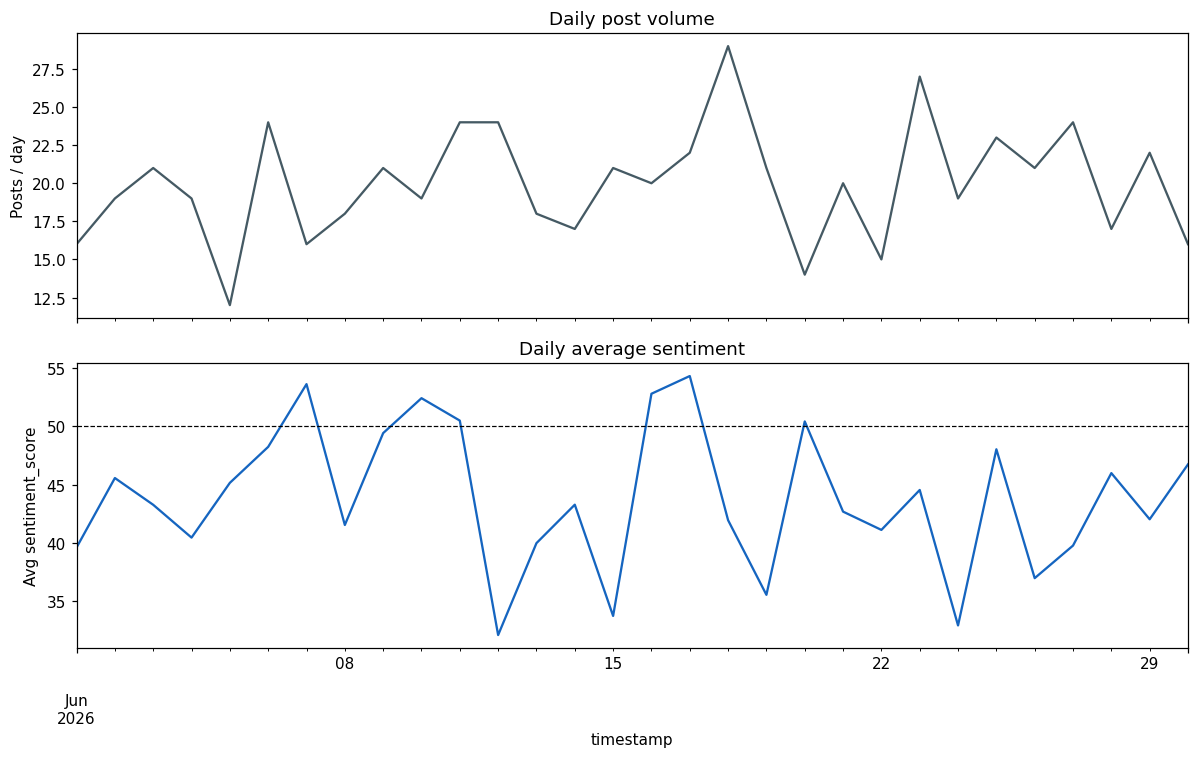

In [13]:
daily = df_brand.set_index("timestamp").resample("D").agg(
    post_count=("id", "count"),
    avg_score=("sentiment_score", "mean"),
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
daily["post_count"].plot(ax=axes[0], color="#455a64")
axes[0].set_ylabel("Posts / day")
axes[0].set_title("Daily post volume")

daily["avg_score"].plot(ax=axes[1], color="#1565c0")
axes[1].axhline(50, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Avg sentiment_score")
axes[1].set_title("Daily average sentiment")
plt.tight_layout()
plt.show()

## 7. Engagement-weighted sentiment

Raw sentiment counts can hide the fact that a small number of negative posts
might be quietly going viral while positive posts get comparatively ignored.


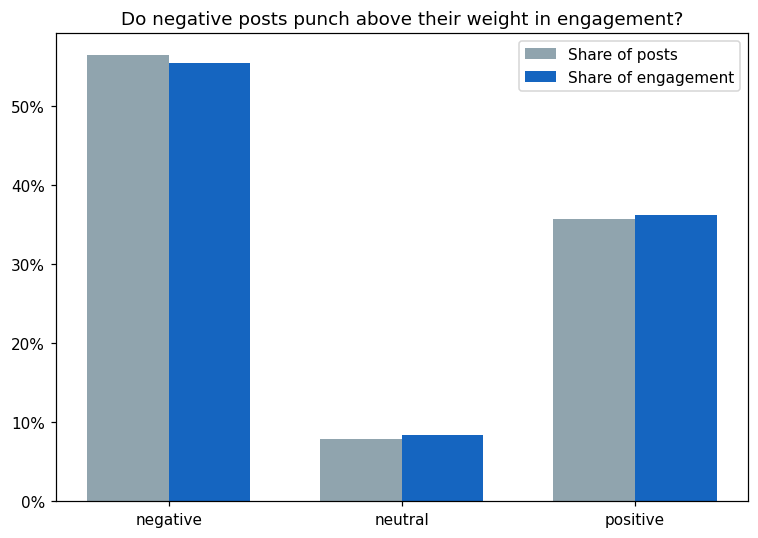

,post_count,total_engagement,avg_engagement,post_share,engagement_share
sentiment,,,,,
negative,338,100063,296.044379,0.564274,0.554673
neutral,47,15063,320.489362,0.078464,0.083498
positive,214,65274,305.018692,0.357262,0.361829


In [14]:
df_brand["engagement"] = df_brand["reactions"] + df_brand["comments"]
eng_by_sentiment = df_brand.groupby("sentiment").agg(
    post_count=("id", "count"),
    total_engagement=("engagement", "sum"),
    avg_engagement=("engagement", "mean"),
)
eng_by_sentiment["post_share"] = eng_by_sentiment["post_count"] / eng_by_sentiment["post_count"].sum()
eng_by_sentiment["engagement_share"] = eng_by_sentiment["total_engagement"] / eng_by_sentiment["total_engagement"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
x = range(len(eng_by_sentiment))
width = 0.35
ax.bar([i - width/2 for i in x], eng_by_sentiment["post_share"], width, label="Share of posts", color="#90a4ae")
ax.bar([i + width/2 for i in x], eng_by_sentiment["engagement_share"], width, label="Share of engagement", color="#1565c0")
ax.set_xticks(list(x))
ax.set_xticklabels(eng_by_sentiment.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Do negative posts punch above their weight in engagement?")
ax.legend()
plt.tight_layout()
plt.show()

eng_by_sentiment


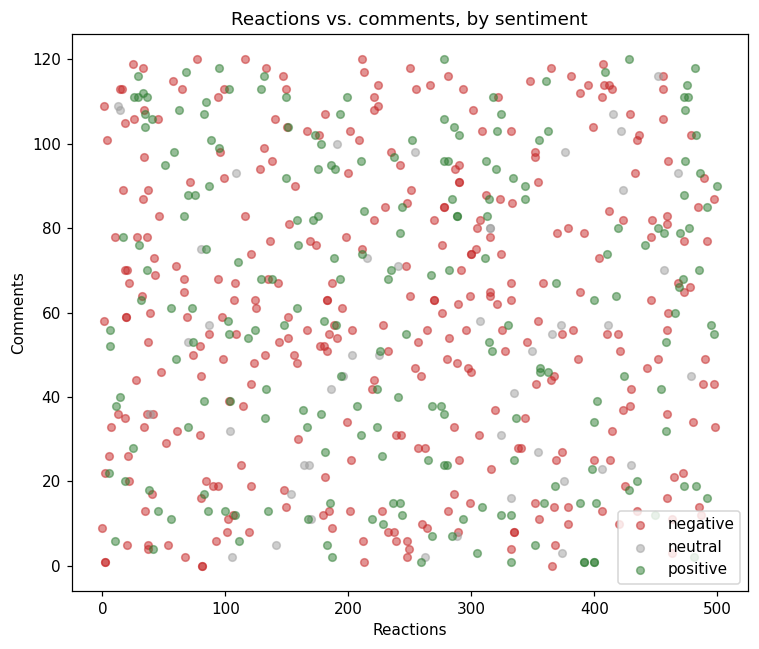

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
for sentiment, group in df_brand.groupby("sentiment"):
    ax.scatter(group["reactions"], group["comments"], alpha=0.5, label=sentiment, color=colors[sentiment], s=25)
ax.set_xlabel("Reactions")
ax.set_ylabel("Comments")
ax.set_title("Reactions vs. comments, by sentiment")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Deep dive — failed transactions as the dominant driver of negative sentiment

This is the main "product call" insight: quantifying how much of the negative
conversation is specifically about money getting stuck or deducted without
the transaction completing, since that's a trust-and-safety issue for a
wallet, not just a UX annoyance.


In [16]:
negatives = df_brand[df_brand["sentiment"] == "negative"]
failed = df_brand[df_brand["topic"] == "failed_transaction"]
failed_negative = failed[failed["sentiment"] == "negative"]

share_of_negative = len(failed_negative) / len(negatives)
share_of_all = len(failed) / len(df_brand)

print(f"failed_transaction posts: {len(failed)} ({share_of_all:.1%} of all brand-relevant posts)")
print(f"Share of ALL negative posts that are about failed transactions: {share_of_negative:.1%}")
print(f"Average sentiment_score, failed_transaction posts: {failed['sentiment_score'].mean():.1f}")
print(f"Average sentiment_score, all negative posts:       {negatives['sentiment_score'].mean():.1f}")

failed_transaction posts: 220 (36.7% of all brand-relevant posts)
Share of ALL negative posts that are about failed transactions: 58.3%
Average sentiment_score, failed_transaction posts: 24.9
Average sentiment_score, all negative posts:       17.8


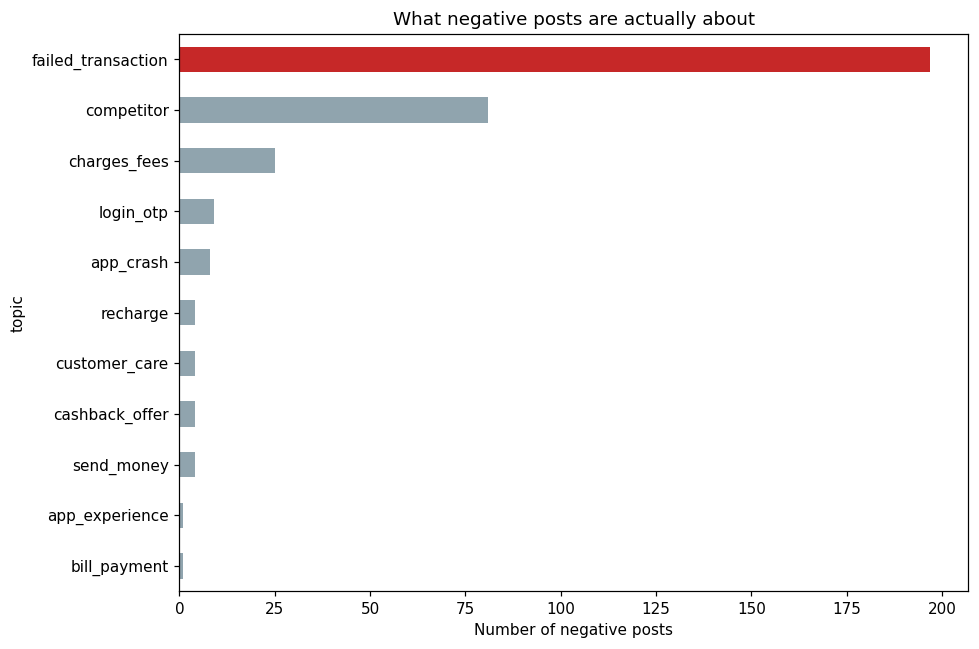

In [17]:
topic_negative_share = (
    df_brand[df_brand["sentiment"] == "negative"]["topic"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ["#c62828" if t == "failed_transaction" else "#90a4ae" for t in topic_negative_share.index]
topic_negative_share.plot(kind="barh", ax=ax, color=bar_colors)
ax.set_xlabel("Number of negative posts")
ax.set_title("What negative posts are actually about")
plt.tight_layout()
plt.show()

In [18]:
# Most-viral failed-transaction complaints — what a brand manager should read first
failed_negative.sort_values("engagement", ascending=False)[
    ["platform", "text", "sentiment_score", "reactions", "comments"]
].head(5)

,platform,text,sentiment_score,reactions,comments
126,TikTok,"landlord কে টাকা পাঠিয়েছি 1 week আগে, এখনো পৌঁছায়নি। TakaPay কী করছে?",9,497,87
59,TikTok,আমার একাউন্ট থেকে 500 টাকা কেটে নিয়েছে কিন্তু Banglalink রিচার্জ হয়নি। TakaPay এর কোনো হেল্প নেই।,16,456,116
198,Facebook,আমার একাউন্ট থেকে 1000 টাকা কেটে নিয়েছে কিন্তু Teletalk রিচার্জ হয়নি। TakaPay এর কোনো হেল্প নেই।,21,492,77
635,Facebook,আমার একাউন্ট থেকে 2000 টাকা কেটে নিয়েছে কিন্তু Teletalk রিচার্জ হয়নি। TakaPay এর কোনো হেল্প নেই।,7,460,96
611,Reddit,2500 taka TakaPay theke katlo but receiver pay nai. 24 ghonta dhore atke ache.,12,473,77


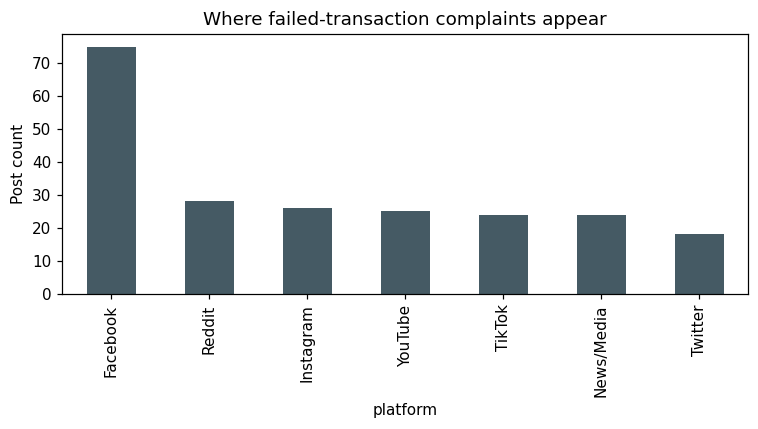

In [19]:
failed["platform"].value_counts().plot(
    kind="bar", figsize=(7, 4), color="#455a64", title="Where failed-transaction complaints appear"
)
plt.ylabel("Post count")
plt.tight_layout()
plt.show()

## 9. Competitor comparison — TakaPay vs. NgoodPay

Posts tagged `topic == competitor` mention a rival wallet, NgoodPay, directly.


In [20]:
competitor = df_brand[df_brand["topic"] == "competitor"]
print(f"{len(competitor)} posts mention the competitor ({len(competitor)/len(df_brand):.1%} of all posts)")
print(competitor["sentiment"].value_counts())
print(f"Average sentiment_score: {competitor['sentiment_score'].mean():.1f}")

81 posts mention the competitor (13.5% of all posts)
sentiment
negative    81
Name: count, dtype: int64
Average sentiment_score: 17.2


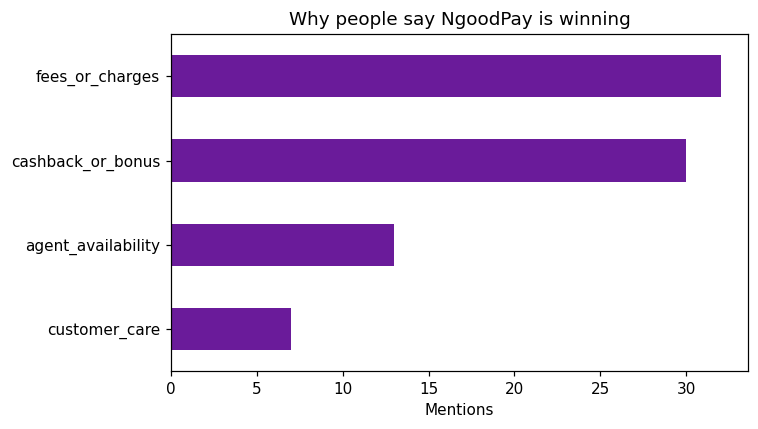

In [21]:
reason_keywords = {
    "cashback_or_bonus": ["cashback", "bonus", "offer"],
    "agent_availability": ["agent"],
    "customer_care": ["customer care", "helpline", "support"],
    "fees_or_charges": ["charge", "fee", "extra"],
}

reason_counts = Counter()
for text in competitor["text"].str.lower():
    for reason, keywords in reason_keywords.items():
        if any(kw in text for kw in keywords):
            reason_counts[reason] += 1

reason_series = pd.Series(reason_counts).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
reason_series.plot(kind="barh", ax=ax, color="#6a1b9a")
ax.set_xlabel("Mentions")
ax.set_title("Why people say NgoodPay is winning")
plt.tight_layout()
plt.show()

In [22]:
competitor[["platform", "text", "sentiment_score"]].sample(
    min(5, len(competitor)), random_state=1
)

,platform,text,sentiment_score
534,Instagram,"Bashundhara e NgoodPay agent beshi, TakaPay agent khuje pai na.",6
222,Facebook,"Banglalink recharge NgoodPay diye korle 1000 e extra bonus, TakaPay e nai.",22
257,Facebook,"Uttara e NgoodPay agent beshi, TakaPay agent khuje pai na.",6
578,Reddit,"NgoodPay er cash out charge 10000 e onek kom, tai TakaPay chere switch korlam.",10
388,Reddit,"NgoodPay app ta ekhon TakaPay theke faster mone hoche, Uttara eo kaj kore.",20


## 10. Language mix

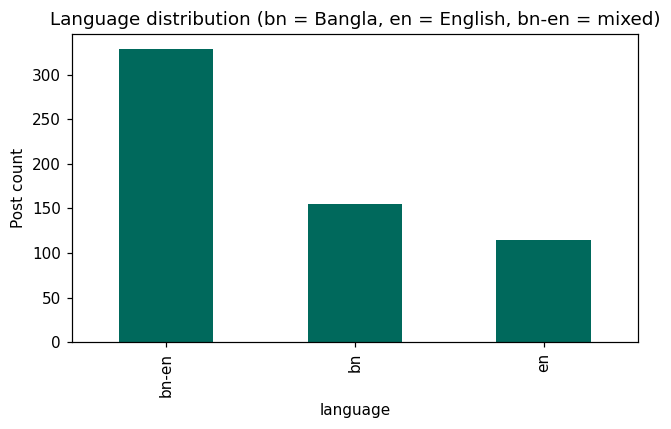

,count
language,
bn-en,329
bn,155
en,115


In [23]:
lang_counts = df_brand["language"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
lang_counts.plot(kind="bar", ax=ax, color="#00695c")
ax.set_ylabel("Post count")
ax.set_title("Language distribution (bn = Bangla, en = English, bn-en = mixed)")
plt.tight_layout()
plt.show()

lang_counts


## 11. Sample-size caution on per-topic stats

Some topics have very few posts (`app_experience`, `product_news` — only 2
each). Their average-sentiment numbers earlier in this notebook are
**not statistically meaningful** and shouldn't be read the same way as
`failed_transaction` (220 posts) or `competitor` (81 posts). This table
makes that visible at a glance rather than letting a striking-looking
percentage from 2 posts pass for a real signal.

In [24]:
topic_reliability = df_brand["topic"].value_counts().to_frame("post_count")
topic_reliability["confidence"] = pd.cut(
    topic_reliability["post_count"],
    bins=[0, 10, 30, 1000],
    labels=["low (n<10) — don't trust the %", "moderate (n<30)", "solid"],
)
topic_reliability


,post_count,confidence
topic,,
failed_transaction,220,solid
competitor,81,solid
cashback_offer,63,solid
send_money,50,solid
recharge,50,solid
charges_fees,30,moderate (n<30)
agent_network,26,moderate (n<30)
bill_payment,24,moderate (n<30)
feature_query,19,moderate (n<30)


## 12. When do failed-transaction complaints happen? (staffing/ops signal)

If complaints cluster around specific hours or days, that's actionable for
support staffing and infra monitoring in a way "36.7% of posts" alone isn't.


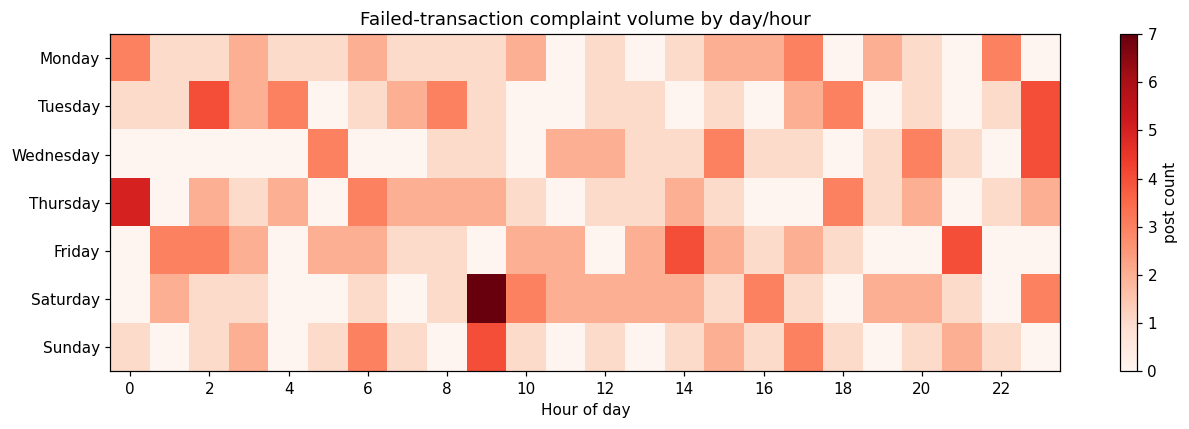

In [25]:
failed_all = df_brand[df_brand["topic"] == "failed_transaction"].copy()
failed_all["hour"] = failed_all["timestamp"].dt.hour
failed_all["day_name"] = failed_all["timestamp"].dt.day_name()

pivot = failed_all.pivot_table(
    index="day_name", columns="hour", values="id", aggfunc="count", fill_value=0
).reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="Reds")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_title("Failed-transaction complaint volume by day/hour")
fig.colorbar(im, ax=ax, label="post count")
plt.tight_layout()
plt.show()


In [26]:
# Busiest hour overall, for a one-line takeaway
busiest_hour = failed_all["hour"].value_counts().idxmax()
busiest_day = failed_all["day_name"].value_counts().idxmax()
print(f"Most complaints land around {busiest_hour}:00, most often on {busiest_day}.")


Most complaints land around 9:00, most often on Saturday.


## 13. Repeat-author check (possible brigading / bot activity)

Worth checking whether a handful of accounts are responsible for a
disproportionate share of posts — that would change how much weight a
brand manager should put on raw volume.


In [27]:
author_counts = df["author"].value_counts()
repeat_authors = author_counts[author_counts > 1]
print(f"{len(repeat_authors)} authors posted more than once "
      f"(out of {df['author'].nunique()} unique authors, {len(df)} total posts).")
print(f"Most active author posted {author_counts.max()} times.")
repeat_authors.head(10)


72 authors posted more than once (out of 583 unique authors, 660 total posts).
Most active author posted 3 times.


,count
author,
Rifat65,3
Fahim74,3
Oishi82,3
Maliha34,3
Tuhin71,3
Sadia5,2
Tuhin20,2
Tanvir29,2
Priya47,2


## 14. Summary of key findings

- **Failed/stuck transactions are the single largest driver of negative
  sentiment** — roughly 58% of all negative posts, well ahead of fees,
  agent access, or app bugs individually.
- **The competitor (NgoodPay) is mentioned exclusively in a negative
  context relative to TakaPay** — mostly around cashback/bonus offers and
  fees, suggesting a pricing/promotions gap rather than a product-quality
  gap.
- **~9% of all "TakaPay" mentions are actually unrelated posts** (off-topic
  content incorrectly flagged as brand mentions) — a data-collection issue
  worth fixing upstream before trusting brand-mention volume as a KPI.
- A small number of sentiment labels disagree with their own numeric score —
  worth a spot-check with whoever owns the labeling pipeline.
- Complaint volume clusters at specific hours/days (see section 12) — useful
  for support staffing, not just a monthly summary stat.

### What I'd recommend a brand manager actually do with this

1. **Treat failed-transaction reliability as the top-line KPI to fix**, not
   general "sentiment." It's the single lever most likely to move the
   negative-sentiment number, and it's a trust issue for a wallet, not
   cosmetic.
2. **Investigate the NgoodPay gap on cashback/fees specifically** — the data
   points at pricing and promotions, not app quality, which changes what
   team should own the response.
3. **Fix the off-topic mislabeling in the data pipeline** before using
   "brand mention volume" as a tracked metric anywhere else — right now
   ~9% of it is noise.
4. Treat any single-digit-n topic breakdown (see section 11) as "worth
   watching," not "worth acting on" until more data comes in.
